# 26 - Where the model stops predicting

**The construction.** F1 and F2 are both Einstein's equations. CLASS satisfies F1 by construction -
it sums $\rho_i$ and takes a square root - and never evaluates F2. So for any observable that depends
on the expansion history there are two determinations *inside the current implementation*:

$$\mathcal{H}_A \;=\; a H \ \ \text{(constraint, what the code uses)},
\qquad
\mathcal{H}_B \;=\; \mathcal{H}_A(x_0) + \int_{x_0}^{x}\!\!\Bigl[-\tfrac{a^2}{2\mathcal{H}_A}(\rho_{\rm tot}+3p_{\rm tot})\Bigr]\mathrm{d}x'$$

along the same trajectory. If they disagree by more than the measurement
error on some quantity, **the model has no prediction for that quantity** at that parameter point.

**Why the acoustic scale is the sharpest probe.** $\theta_* = r_s(z_*)/D_M(z_*)$, and

- $r_s$ is fixed by physics at $z\approx1060$, long before injection ($a_t \gg a_{\rm rec}$), so it is
  **identical in both branches** and cancels from the ratio entirely - the calculation below never
  needs it;
- $D_M$ is $\int\mathrm{d}z/H$, dominated by low $z$, which is exactly where the two branches have
  separated.

And $\theta_*$ is measured to 0.03%, better than anything else in cosmology.


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5,
    'figure.dpi': 300,
})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628']

omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0_in = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0_in,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
A_REC = 1.0/(1.0 + 1090.0)

N_LOGA   = 20001
N_Q      = 5001 
FIDUCIAL = dict(f_acc=0.1, eta=0.1, kappa=12.1, a_t=0.133)
A_START  = 5e-4

OFFSET_ETA = 1e-6

SIGMA = {
    'theta_star':  0.00031/1.04109,    # Planck 2018: 100*theta_* = 1.04109 +/- 0.00031
    'H0':          0.54/67.36,
    # 't0':          0.023/13.797,
    # 'sigma8_exp':  0.0060/0.8111,      # via the growing mode - measured here
    # 'sigma8_pert': 0.0060/0.8111,      # via Delta_h - imported, see below
    # 'DM_z0.51':    0.010,
    # 'DM_z2.33':    0.020,
    # 'H_z0.51':     0.015,
    # 'H_z2.33':     0.025,
}

DELTA_H_AT_FIDUCIAL = 8.5e-3

def accdm_params(f_acc, eta, kappa, a_t, mass_GeV=1e16, n_q=None):
    n_q  = N_Q if n_q is None else n_q
    ocdm = omega_cdm0*(1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': mass_GeV, 'm_cdm_in_GeV': mass_GeV,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(mass_GeV*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {:d}'.format(n_q), 'N_ur': 0.00441,
              'background_Nloga': N_LOGA})
    return p


def lcdm_params():
    p = dict(base_params)
    p.update({'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02', 'T_ncdm': '0.71611',
              'ncdm_quadrature_strategy': '0', 'ncdm_N_momentum_bins': '15',
              'N_ur': 0.00441, 'background_Nloga': N_LOGA})
    return p


def run_background(params):
    cosmo = Class(); cosmo.set(params); cosmo.compute()
    bg = cosmo.get_background()
    z_star = 1089.9
    for name in ('z_rec', 'z_star'):
        try:
            z_star = float(cosmo.get_current_derived_parameters([name])[name])
            break
        except Exception:
            pass
    age = float(cosmo.age())
    cosmo.struct_cleanup(); cosmo.empty()
    return dict(bg=bg, z_star=z_star, age=age)


def cum_integral(y, x):
    '''Cumulative integral, O(h^4) on the uniform ln a grid (Euler-Maclaurin).'''
    cum = np.concatenate(([0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))))
    h  = float(np.median(np.diff(x)))
    dy = np.gradient(y, x)
    return cum - (h*h/12.0)*(dy - dy[0])


def branches(bg, a_start=A_START):
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda k: np.asarray(bg[k])[order]
    a, H   = a_all[order], take('H [1/Mpc]')
    rho, p = take('(.)rho_tot'), take('(.)p_tot')
    units  = float(np.max(np.abs(H**2/rho - 1.0)))

    sel = a >= a_start
    a, H, rho, p = a[sel], H[sel], rho[sel], p[sel]
    x  = np.log(a)
    HA = a*H
    HB = HA[0] + cum_integral(-(a**2)*(rho + 3.0*p)/(2.0*HA), x)
    return dict(a=a, x=x, HA=HA, HB=HB, Delta=HB/HA - 1.0, units=units)


BAO_Z = (0.51, 2.33)

def growth_ratio(a, x, HA, HB):
    '''Fractional ambiguity in the linear growing mode, hence in sigma_8.

        D(a)  proportional to  H(a) * int_0^a da' / (a' H(a'))^3
        
    '''
    IA = cum_integral(a/HA**3, x)
    IB = cum_integral(a/HB**3, x)
    DA = (HA[-1]/a[-1])*IA[-1]
    DB = (HB[-1]/a[-1])*IB[-1]
    return float(DB/DA - 1.0)


def observable_ambiguity(br, z_star, age_gyr, delta_h=0.0):
    '''Fractional (B - A)/A for each observable.'''
    a, x, HA, HB = br['a'], br['x'], br['HA'], br['HB']
    IA, IB = cum_integral(1.0/HA, x), cum_integral(1.0/HB, x)   # conformal time
    JA, JB = cum_integral(a/HA, x),   cum_integral(a/HB, x)     # proper time

    def dist(I, a_from):
        return I[-1] - I[int(np.searchsorted(a, a_from))]

    out = {}
    a_star = 1.0/(1.0 + z_star)
    DA, DB = dist(IA, a_star), dist(IB, a_star)
    out['theta_star']  = -(DB - DA)/DA         # theta = r_s/D_M, r_s identical
    out['H0']          = float(HB[-1]/HA[-1] - 1.0)
    # out['t0']          = float((JB[-1] - JB[0]) - (JA[-1] - JA[0]))/(age_gyr*3.0660e2)
    # out['sigma8_exp']  = growth_ratio(a, x, HA, HB)
    # out['sigma8_pert'] = delta_h

    for z in BAO_Z:
        af = 1.0/(1.0 + z)
        dA, dB = dist(IA, af), dist(IB, af)
        i = int(np.searchsorted(a, af))
        out['DM_z{:g}'.format(z)] = (dB - dA)/dA
        out['H_z{:g}'.format(z)]  = float(HB[i]/HA[i] - 1.0)
    return out


def fit_linear(etas, values):
    '''values = A + B*eta.  Returns offset A, slope B, and the worst residual.'''
    etas, values = np.asarray(etas, float), np.asarray(values, float)
    B, A = np.polyfit(etas, values, 1)
    return float(A), float(B), float(np.max(np.abs(values - (A + B*etas))))


print('setup ready.  A_START = {:g}, a_star ~ {:.2e}, margin {:.2f} e-folds'.format(
      A_START, 1/1090., np.log((1/1090.)/A_START)))
print('daughter q-bins = {:d} (odd), offset reference eta = {:g}'.format(N_Q, OFFSET_ETA))


setup ready.  A_START = 0.0005, a_star ~ 9.17e-04, margin 0.61 e-folds
daughter q-bins = 5001 (odd), offset reference eta = 1e-06


## 1. Null test in LCDM

In [28]:
run_l = run_background(lcdm_params())
br_l  = branches(run_l['bg'])
amb_l = observable_ambiguity(br_l, run_l['z_star'], run_l['age'], delta_h=0.0)

print('flatness / unit check  max|H^2/rho_tot - 1| = {:.3e}'.format(br_l['units']))
print('z_star = {:.2f},  a_star = {:.4e},  age = {:.4f} Gyr'.format(
      run_l['z_star'], 1.0/(1.0 + run_l['z_star']), run_l['age']))
print()
print('LCDM NULL - every entry should be ~0')
print('  {:<12} {:>13} {:>12} {:>10}'.format('observable', 'ambiguity', '1-sigma', 'in sigma'))
for k in SIGMA:
    print('  {:<12} {:>+13.3e} {:>12.3e} {:>10.3f}'.format(
          k, amb_l[k], SIGMA[k], abs(amb_l[k])/SIGMA[k]))
NULL_FLOOR = max(abs(amb_l[k]) for k in SIGMA)
print('\n  estimator floor: {:.2e}'.format(NULL_FLOOR))


flatness / unit check  max|H^2/rho_tot - 1| = 2.220e-16
z_star = 1088.77,  a_star = 9.1762e-04,  age = 13.7985 Gyr

LCDM NULL - every entry should be ~0
  observable       ambiguity      1-sigma   in sigma
  theta_star      -2.429e-09    2.978e-04      0.000
  H0              -3.146e-09    8.017e-03      0.000

  estimator floor: 3.15e-09


## 2. The accDM offset

In [29]:
print('offset in Delta(1), measured at eta = {:g}'.format(OFFSET_ETA))
print('  {:>8}'.format('N_Q') + ''.join('{:>15}'.format('a0={:g}'.format(s))
                                        for s in (3e-4, 5e-4, 8e-4)))
offset_runs = {}
for n_q in (201, 501, 1001):
    pars = dict(FIDUCIAL); pars['eta'] = OFFSET_ETA
    r = run_background(accdm_params(n_q=n_q, **pars))
    offset_runs[n_q] = r
    row = '  {:>8d}'.format(n_q)
    for a0 in (3e-4, 5e-4, 8e-4):
        row += '{:>15.3e}'.format(float(branches(r['bg'], a_start=a0)['Delta'][-1]))
    print(row)


offset in Delta(1), measured at eta = 1e-06
       N_Q      a0=0.0003      a0=0.0005      a0=0.0008
       201      6.665e-03      6.665e-03      6.665e-03
       501     -7.087e-05     -7.087e-05     -7.087e-05
      1001     -1.379e-06     -1.377e-06     -1.375e-06


## 3. Fiducial


In [30]:
def structural_ambiguity(pars, delta_h_at_fid=DELTA_H_AT_FIDUCIAL, n_q=None,
                         a_start=A_START):
    '''Ambiguity with the eta-independent numerical offset removed.'''
    hi = run_background(accdm_params(n_q=n_q, **pars))
    lo_pars = dict(pars); lo_pars['eta'] = OFFSET_ETA
    lo = run_background(accdm_params(n_q=n_q, **lo_pars))

    dh = delta_h_at_fid*pars['eta']*pars['f_acc']/(FIDUCIAL['eta']*FIDUCIAL['f_acc'])
    a_hi = observable_ambiguity(branches(hi['bg'], a_start), hi['z_star'], hi['age'], dh)
    a_lo = observable_ambiguity(branches(lo['bg'], a_start), lo['z_star'], lo['age'], 0.0)
    corrected = {k: a_hi[k] - a_lo.get(k, 0.0) for k in a_hi}
    corrected['sigma8_pert'] = dh              # imported: no offset to remove
    return dict(raw=a_hi, offset=a_lo, corrected=corrected,
                branch=branches(hi['bg'], a_start), run=hi)


fid = structural_ambiguity(FIDUCIAL)
print('accDM', FIDUCIAL)
# print('  Delta(a=1)  raw {:+.4e}   offset {:+.4e}   structural {:+.4e}'.format(
#       float(fid['branch']['Delta'][-1]),
#       float(branches(run_background(accdm_params(**dict(FIDUCIAL, eta=OFFSET_ETA))
#                                     )['bg'])['Delta'][-1]),
#       float(fid['branch']['Delta'][-1]) -
#       float(branches(run_background(accdm_params(**dict(FIDUCIAL, eta=OFFSET_ETA))
#                                     )['bg'])['Delta'][-1])))
print()
print('  {:<12} {:>12} {:>12} {:>13} {:>12} {:>9}'.format(
      'observable', 'raw', 'offset', 'structural', '1-sigma', 'in sigma'))
worst, worst_k = 0.0, None
for k in SIGMA:
    c = fid['corrected'][k]
    r = abs(c)/SIGMA[k]
    if r > worst:
        worst, worst_k = r, k
    print('  {:<12} {:>+12.3e} {:>+12.3e} {:>+13.3e} {:>12.3e} {:>9.2f}'.format(
          k, fid['raw'][k], fid['offset'].get(k, 0.0), c, SIGMA[k], r))
print()
print('  worst: {} at {:.1f} sigma   (estimator floor {:.1e})'.format(
      worst_k, worst, NULL_FLOOR))


accDM {'f_acc': 0.1, 'eta': 0.1, 'kappa': 12.1, 'a_t': 0.133}

  observable            raw       offset    structural      1-sigma  in sigma
  theta_star     -3.620e-03   +3.772e-07    -3.620e-03    2.978e-04     12.16
  H0             -5.865e-03   +4.051e-07    -5.866e-03    8.017e-03      0.73

  worst: theta_star at 12.2 sigma   (estimator floor 3.1e-09)


## 4. Linearity


In [31]:
ETA_SCAN = [1e-3, 1e-2, 1e-1]
raw_scan = {}
for e in ETA_SCAN:
    pars = dict(FIDUCIAL); pars['eta'] = e
    r = run_background(accdm_params(**pars))
    raw_scan[e] = observable_ambiguity(branches(r['bg']), r['z_star'], r['age'], 0.0)

print('fit  ambiguity = A + B*eta   at f_acc = {:g}, a_t = {:g}'.format(
      FIDUCIAL['f_acc'], FIDUCIAL['a_t']))
print('  {:<12} {:>14} {:>14} {:>13} {:>14}'.format(
      'observable', 'A (offset)', 'B (slope)', 'max resid', 'B*eta_fid'))
slopes = {}
for k in SIGMA:
    if k == 'sigma8_pert':
        continue
    A, B, res = fit_linear(ETA_SCAN, [raw_scan[e][k] for e in ETA_SCAN])
    slopes[k] = B*FIDUCIAL['eta']
    print('  {:<12} {:>+14.4e} {:>+14.4e} {:>13.2e} {:>+14.4e}'.format(k, A, B, res, slopes[k]))
slopes['sigma8_pert'] = DELTA_H_AT_FIDUCIAL


fit  ambiguity = A + B*eta   at f_acc = 0.1, a_t = 0.133
  observable       A (offset)      B (slope)     max resid      B*eta_fid
  theta_star      +1.1145e-06    -3.6208e-02      6.13e-07    -3.6208e-03
  H0              +5.9256e-08    -5.8654e-02      3.54e-07    -5.8654e-03


## 5. The boundary

Everything scales linearly in $\eta f_{\rm acc}$, so the boundary follows analytically once the
structural amplitude is known:

$$\bigl(\eta f_{\rm acc}\bigr)_i^{\rm max} \;=\; \bigl(\eta f_{\rm acc}\bigr)_{\rm fid}\cdot
\frac{\sigma_i}{\lvert\text{structural}_i\rvert} .$$


In [32]:
eta_f_fid = FIDUCIAL['eta']*FIDUCIAL['f_acc']
print('largest eta*f_acc at which the model still predicts each observable')
print('  {:<12} {:>15} {:>13} {:>16} {:>16}'.format(
      'observable', 'structural', 'in sigma', 'max eta*f_acc', 'min m_acc/f_acc'))
limits = {}
for k in SIGMA:
    amp = abs(fid['corrected'][k])
    ratio = amp/SIGMA[k]
    limits[k] = eta_f_fid/ratio if ratio > 0 else np.inf
    print('  {:<12} {:>15.3e} {:>13.2f} {:>16.3e} {:>16.2e}'.format(
          k, amp, ratio, limits[k], 1e11/limits[k] if limits[k] > 0 else np.inf))
binding = min(limits, key=limits.get)
print()
print('  BINDING: {}  ->  eta*f_acc <= {:.2e},  m_acc >= {:.2e} * f_acc GeV'.format(
      binding, limits[binding], 1e11/limits[binding]))


largest eta*f_acc at which the model still predicts each observable
  observable        structural      in sigma    max eta*f_acc  min m_acc/f_acc
  theta_star         3.620e-03         12.16        8.225e-04         1.22e+14
  H0                 5.866e-03          0.73        1.367e-02         7.32e+12

  BINDING: theta_star  ->  eta*f_acc <= 8.23e-04,  m_acc >= 1.22e+14 * f_acc GeV


## 6. Dependence on $a_t$

In [33]:
print('a_rec ~ {:.2e}.  Any a_t below this invalidates the "r_s cancels" argument.'.format(A_REC))
print()
print('  {:>7} {:>16} {:>12} {:>16}'.format('a_t', 'theta_star', 'in sigma', 'max eta*f_acc'))
at_rows = {}
for a_t in (0.02, 0.05, 0.133, 0.40):
    pars = dict(FIDUCIAL); pars['a_t'] = a_t
    s = structural_ambiguity(pars)
    amp = abs(s['corrected']['theta_star'])
    ratio = amp/SIGMA['theta_star']
    at_rows[a_t] = (s, ratio, eta_f_fid/ratio if ratio > 0 else np.inf)
    print('  {:>7.3f} {:>+16.4e} {:>12.1f} {:>16.3e}'.format(
          a_t, s['corrected']['theta_star'], ratio, at_rows[a_t][2]))


a_rec ~ 9.17e-04.  Any a_t below this invalidates the "r_s cancels" argument.

      a_t       theta_star     in sigma    max eta*f_acc
    0.020      -1.1142e-02         37.4        2.673e-04
    0.050      -6.7446e-03         22.7        4.415e-04
    0.133      -3.6201e-03         12.2        8.225e-04
    0.400      -1.1396e-03          3.8        2.613e-03


printed size 6.50 x 3.00 in


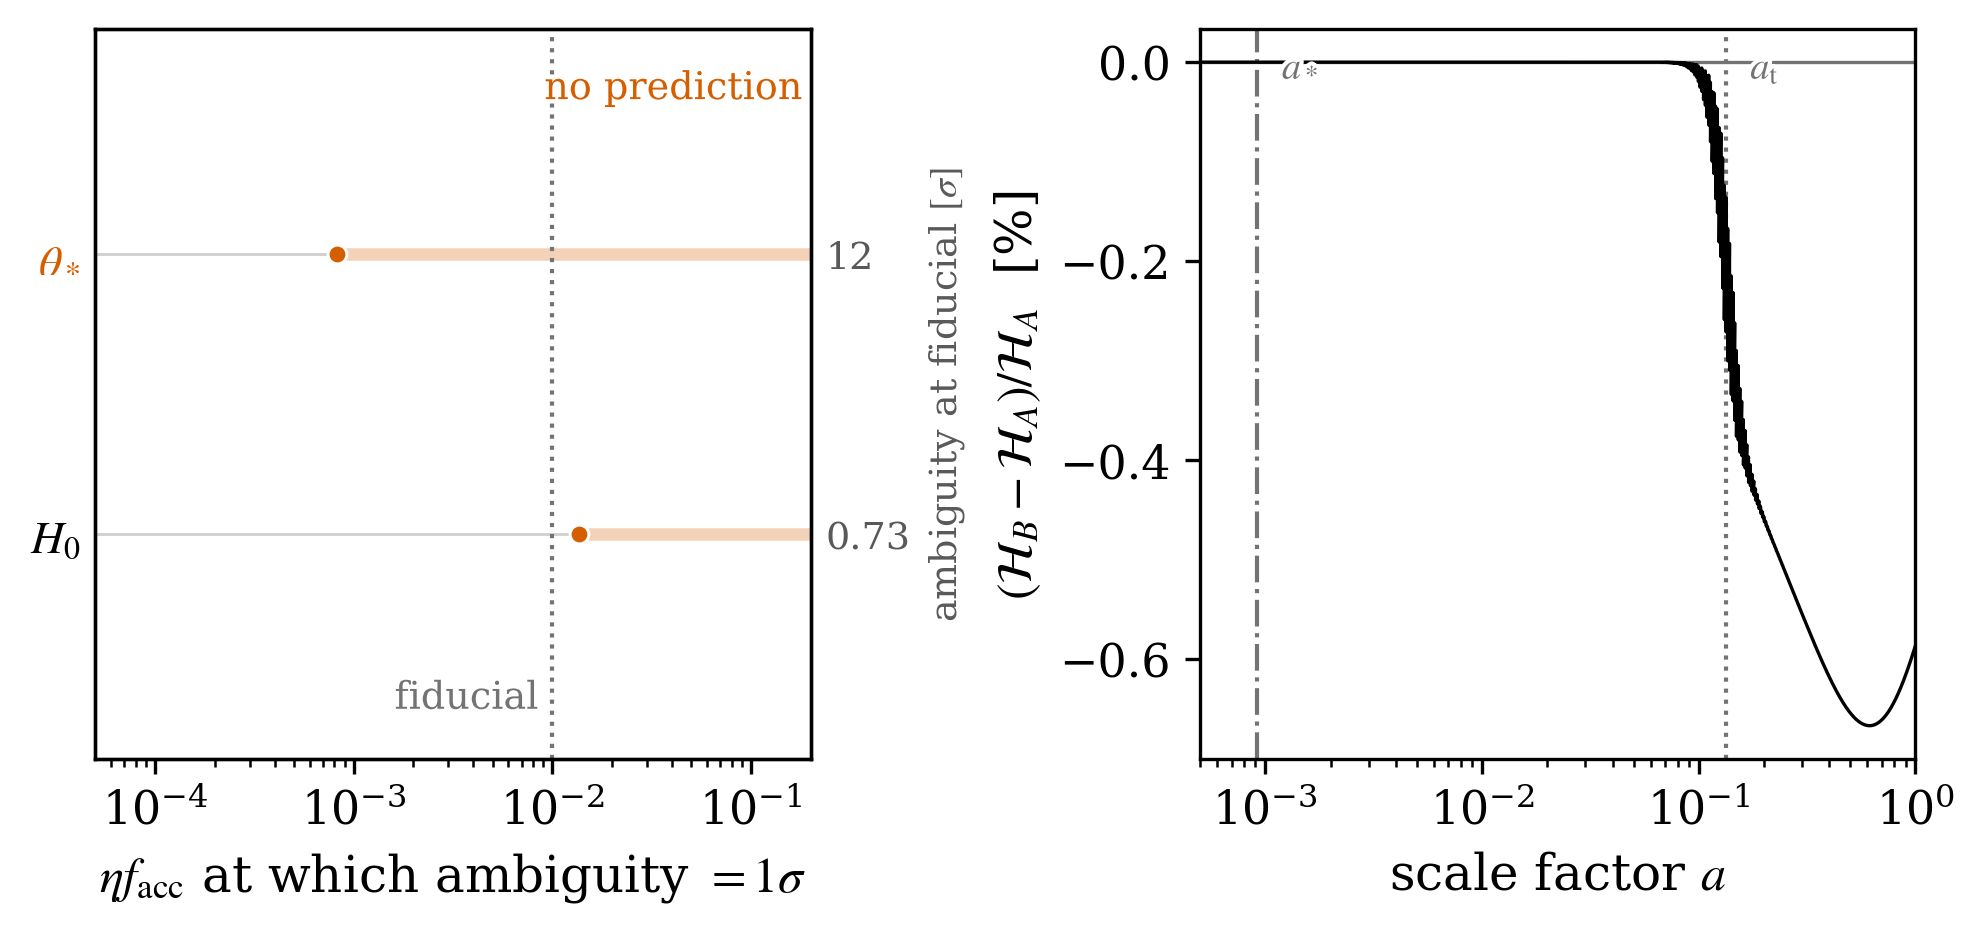

In [36]:
# ---------------------------------------------------------------- figure cell
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import figkit as fk
    fk.use("quick", font="palatino", usetex=True, cycle="cb")
    stroke, log_minor = fk.stroke, fk.log_minor_ticks
    C_FAIL = fk.CB_COLORS["red"]
except ImportError:                      # plain-matplotlib fallback
    import matplotlib.patheffects as pe
    from matplotlib import ticker
    C_FAIL = "#D55E00"
    stroke = lambda lw=2.0: [pe.Stroke(linewidth=lw, foreground="white"), pe.Normal()]
    def log_minor(ax, axis="both"):
        for n in (("x", "y") if axis == "both" else (axis,)):
            a = getattr(ax, n + "axis")
            a.set_major_locator(ticker.LogLocator(10.0, (1.0,), numticks=100))
            a.set_minor_locator(ticker.LogLocator(10.0, np.arange(2, 10)*0.1, numticks=100))
            a.set_minor_formatter(ticker.NullFormatter())
        return ax

C_REF = "0.45"
PCT = r"[\%]" if mpl.rcParams["text.usetex"] else r"[%]"

# LaTeX display names; unknown keys fall back to the raw string.
LABELS = {
    "theta_star":  r"$\theta_*$",
    "t0":          r"$t_0$",
    "sigma8_exp":  r"$\sigma_8$ (exp)",
    "sigma8_pert": r"$\sigma_8$ (pert)",
    "H0":          r"$H_0$",
    "DM_z0.51":    r"$D_M(z\!=\!0.51)$",
    "DM_z2.33":    r"$D_M(z\!=\!2.33)$",
    "H_z0.51":     r"$H(z\!=\!0.51)$",
    "H_z2.33":     r"$H(z\!=\!2.33)$",
}
lab = lambda k: LABELS.get(k, k.replace("_", r"\_"))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(6.5, 3.0), constrained_layout=True)

# --- (a) ------------------------------------------------------------------
ratio  = {k: abs(fid["corrected"][k]) / SIGMA[k] for k in SIGMA}  # sigma, at fiducial
thresh = {k: eta_f_fid / ratio[k] for k in SIGMA}                 # eta*f_acc at 1 sigma
order = sorted(thresh, key=thresh.get)                            # most fragile on top
y = np.arange(len(order))[::-1]

XMIN = 10 ** (np.floor(np.log10(min(thresh.values()))) - 0.3)
XMAX = 10 ** (np.ceil(np.log10(max(thresh.values()))) + 0.3)
axL.set_xscale("log")
axL.set_xlim(XMIN, XMAX)
axL.set_ylim(-0.8, len(order) - 0.2)

for yi, k in zip(y, order):
    xt = thresh[k]
    axL.plot([XMIN, xt], [yi, yi], color="0.82", lw=0.7, zorder=1)
    axL.plot([xt, XMAX], [yi, yi], color=C_FAIL, lw=3.0, alpha=0.28,
             solid_capstyle="butt", zorder=1)
    axL.plot([xt], [yi], "o", ms=4.5, color=C_FAIL, mec="white", mew=0.7, zorder=4)

axL.axvline(eta_f_fid, color=C_REF, ls=":", lw=1.0, zorder=2)
axL.text(eta_f_fid * 0.85, -0.65, "fiducial", fontsize="small", color=C_REF,
         ha="right", va="bottom", path_effects=stroke(2.0))
axL.text(XMAX / 1.1, len(order) - 0.35, "no prediction", fontsize="small",
         color=C_FAIL, ha="right", va="top", path_effects=stroke(2.0))

axL.set_yticks(y)
axL.set_yticklabels([lab(k) for k in order])
axL.tick_params(axis="y", length=0, right=False)
for t, k in zip(axL.get_yticklabels(), order):
    if thresh[k] < eta_f_fid:                       # broken already at fiducial
        t.set_color(C_FAIL)

axA2 = axL.twinx()                                   # value at the fiducial
axA2.set_ylim(axL.get_ylim())
axA2.set_yticks(y)
axA2.set_yticklabels(["%.2g" % ratio[k] for k in order], fontsize="small", color="0.35")
axA2.tick_params(axis="y", length=0)
axA2.set_ylabel(r"ambiguity at fiducial $[\sigma]$", fontsize="small", color="0.35")

axL.set_xlabel(r"$\eta f_{\mathrm{acc}}$ at which ambiguity $=1\sigma$")
log_minor(axL, "x")

# --- (b) ------------------------------------------------------------------
a_star = 1.0 / (1.0 + fid["run"]["z_star"])
axR.semilogx(fid["branch"]["a"], 100.0 * fid["branch"]["Delta"],
             color="black", lw=0.8, zorder=3)
axR.axhline(0.0, color=C_REF, lw=0.8, zorder=1)
axR.set_xlim(A_START, 1.0)

for xv, txt, ls in ((a_star, r"$a_*$", "-."),
                    (FIDUCIAL["a_t"], r"$a_{\mathrm{t}}$", ":")):
    axR.axvline(xv, color=C_REF, ls=ls, lw=1.0, zorder=2)
    axR.text(xv * 1.3, 0.97, txt, transform=axR.get_xaxis_transform(),
             ha="left", va="top", fontsize="small", color=C_REF,
             path_effects=stroke(2.0))

# axR.text(0.03, 0.55, r"$\Lambda$CDM null $\equiv 0$", transform=axR.transAxes,
#          ha="left", va="bottom", fontsize="small", color=C_REF)
axR.set_xlabel(r"scale factor $a$")
axR.set_ylabel(r"$(\mathcal{H}_B-\mathcal{H}_A)/\mathcal{H}_A$  " + PCT)
log_minor(axR, "x")

# --- checks ---------------------------------------------------------------
d = 100.0 * np.asarray(fid["branch"]["Delta"])
lo, hi = axR.get_ylim()
if d.min() < lo or d.max() > hi:
    print("WARNING: panel (b) clips data", d.min(), d.max(), lo, hi)
off = [k for k, v in thresh.items() if not (XMIN <= v <= XMAX)]
if off:
    print("WARNING: threshold off-panel:", off)
print("printed size %.2f x %.2f in" % tuple(fig.get_size_inches()))

plt.show()

## Verdict


In [35]:
print('Estimator validation:')
print('  LCDM null, worst observable      {:.2e}'.format(NULL_FLOOR))
print('  linearity fit, worst residual    {:.2e}'.format(
      max(fit_linear(ETA_SCAN, [raw_scan[e][k] for e in ETA_SCAN])[2]
          for k in SIGMA if k != 'sigma8_pert')))
print()
print('At the fiducial point {}:'.format(FIDUCIAL))
print('  theta_* ambiguous by             {:+.3f}%  against a 0.030% measurement'.format(
      100*fid['corrected']['theta_star']))
print('  worst observable                 {} at {:.1f} sigma'.format(worst_k, worst))
print()
print('BOUNDARY (binding observable: {})'.format(binding))
print('  eta * f_acc  <=  {:.2e}'.format(limits[binding]))
print('  m_acc        >=  {:.2e} * f_acc  GeV'.format(1e11/limits[binding]))
# print('  tightens as a_t decreases; a_t < a_rec breaks the r_s cancellation entirely.')
print()
print('=' * 76)


Estimator validation:
  LCDM null, worst observable      3.15e-09
  linearity fit, worst residual    6.13e-07

At the fiducial point {'f_acc': 0.1, 'eta': 0.1, 'kappa': 12.1, 'a_t': 0.133}:
  theta_* ambiguous by             -0.362%  against a 0.030% measurement
  worst observable                 theta_star at 12.2 sigma

BOUNDARY (binding observable: theta_star)
  eta * f_acc  <=  8.23e-04
  m_acc        >=  1.22e+14 * f_acc  GeV

